# Single Match Analysis - Final Match




## 0. Setup - Imports and Configuration

In [612]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import config
from src.analysis.game_utils import game_summary
from src.analysis.prediction_utils import normalize_predictions, print_top_predictions, get_top_indices, create_top_sequences, visualize_top_sequences
from src.analysis.visualization import plot_possession_actions
from src.data.data_loader import load_socceraction_match
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence_preprocessor import SequencePreprocessor, PreprocessingMode
from src.ml.preprocessing.xthreat import get_default_xt_model


In [613]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [614]:
match_id = 3943043
selected_match, selected_events = load_socceraction_match("data/statsbomb/data", 55, 282, match_id)

print(f"Loaded match: {game_summary(selected_match)} with {len(selected_events)} events")

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loaded match: Spain 2 : 1 England (Final) [14.07.2024] with 3312 events


## 2. Load Trained Model

In [615]:
# Load the best trained model
MODEL_TYPE = 'attention_lstm'  # Change to 'transformer' if using the transformer model
MODEL_DIR = 'generated/attention_lstm_attention_lstm_large_20260214_170158'

model = load_model(MODEL_TYPE, MODEL_DIR)
print(f"Model type: {MODEL_TYPE}")


Model type: attention_lstm


In [616]:
# Display model architecture
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 8, 46)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 8, 46)     │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 8, 46)     │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 8)         │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 8, 256)    │    179,200 │ masking_1[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 256)    │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 8, 128)    │    197,120 │ dropout_3[0][0],  │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 8, 128)    │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ [(None, 128),     │        136 │ dropout_4[0][0],  │
│ (AttentionLayer)    │ (None, 8)]        │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value (Dense)       │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,154,333 (4.40 MB)

 Trainable params: 384,777 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 769,556 (2.94 MB)

## 3. Preprocess Data for Analysis

In [617]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p = preprocessor.process_match(match_id, selected_match, selected_events, mode=PreprocessingMode.VALIDATION)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events (mode: validation)
 → Generated 124 sequences, 124 labels for match 3943043
Validation set preprocessed: 124 sequences


In [618]:
X.shape

(124, 8, 46)

In [619]:
p.shape

(124,)

In [620]:
p[0:2]

array([   game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name      player_name  possession type_name  duration  under_pressure  counterpress   xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
       0  3943043  152820f0-6ca9-4df3-943b-a67d568ff472          1         0.340      768    99174.0  52.45625  34.0425   22.18125  35.0625        0          1            5          0   England    Kobbie Mainoo           2      Pass  2.529454           False         False  0.0                 768              England  0.010165 -30.2750   1.020  30.292178  3.107914      0.000                0
       1  3943043  9c107df3-a3c8-4ad5-bc35-00214087a105          1         2.870      768     3468.0  22.18125  35.0625   25.06875  41.1825       21          1            0          1   England  Jordan Pickford

## 4. Analysis


#### Make predictions on match sequences

In [621]:
predictions = model.predict(X, batch_size=32, verbose=0)
predictions

{'value': array([[0.04565348],
        [0.01486147],
        [0.03225082],
        [0.01432724],
        [0.01247531],
        [0.01772052],
        [0.01932665],
        [0.27335292],
        [0.06189746],
        [0.01340898],
        [0.05809063],
        [0.01074087],
        [0.03023241],
        [0.01358927],
        [0.0208518 ],
        [0.01751445],
        [0.08662526],
        [0.16260754],
        [0.14512539],
        [0.01476098],
        [0.24268943],
        [0.05923451],
        [0.01258847],
        [0.09997454],
        [0.23574062],
        [0.01801968],
        [0.03274605],
        [0.01092404],
        [0.02817765],
        [0.01441349],
        [0.16042049],
        [0.01171539],
        [0.10000565],
        [0.02061007],
        [0.13651057],
        [0.01447839],
        [0.02370829],
        [0.01839589],
        [0.05797181],
        [0.02890223],
        [0.01214302],
        [0.01413276],
        [0.02451912],
        [0.03200207],
        [0.01037184],
 

#### Predictions

In [622]:
predicted_values, attention_weights = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")
print(f"Has attention weights: {attention_weights is not None}")

Total sequences analyzed: 124
Sum of all predicted values: 8.108
Has attention weights: True


#### LSTM Attention Weights and Predicted Values

#### Get top 8 sequences by predicted value

In [623]:
number_of_top_predictions = 8
print_top_predictions(predicted_values, p, None, number_of_top_predictions, attention_weights)


Top 8 sequences with highest predicted values:

1. Possession id =       game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name             player_name  possession type_name  duration  under_pressure  counterpress        xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
1836  3943043  77013fec-81ba-420d-855d-a0fb28419ed6          2      2448.556      772     6655.0  43.09375  28.0925   45.98125  28.4325       21          1            0       1836     Spain        Fabián Ruiz Peña         136     Carry  0.838384            True         False  0.000000                 772                Spain  0.014846   2.8875   0.340   2.907448  0.117209      0.993                0
1837  3943043  f06a66c5-ac21-4f2f-ad39-b144ab8e1418          2      2449.394      772     6655.0  45.98125  28.4325   55.43125

#### Top possessions information

In [624]:
sorted_indices = get_top_indices(predicted_values)
top_indices = sorted_indices[:50]
top_indices

array([118, 119,   7, 106, 120,  51,  20, 116,  90,  94,  49,  24,  59,
       103,  67, 111,  63,  17,  30,  69,  18,  34, 107,  87, 100,  32,
        23,  96,  16,  64, 115,   8, 101,  21,  10,  38, 108,  78,  73,
        48,  82,  85, 105,   0,  95,  54,  92,  62,  57,  91])

#### Save top possessions dataframe

In [625]:
p[2]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
25,3943043,cf968bfa-cdd1-4e9b-a25c-f463f6a25c01,1,68.606,772,22128.0,20.34375,16.9575,23.93125,39.3125,0,1,5,25,Spain,Robin Aime Robert Le Normand,4,Pass,1.854941,False,False,0.0,772,Spain,0.010165,3.5875,22.355,22.641029,1.411674,1.353,0
26,3943043,7ffbc20c-fb5b-4dd6-a21e-8b3e38e6df58,1,70.461,772,4353.0,23.93125,39.3125,36.88125,46.8775,21,1,0,26,Spain,Aymeric Laporte,4,Carry,4.706537,False,False,0.0,772,Spain,0.012692,12.9500,7.565,14.997724,0.528698,1.855,0
27,3943043,264bfc53-81bc-4f0d-bb60-ba153a2851e4,1,75.168,772,4353.0,36.88125,46.8775,31.10625,20.7825,0,1,4,27,Spain,Aymeric Laporte,4,Pass,1.753018,False,False,0.0,772,Spain,0.011105,-5.7750,-26.095,26.726385,-1.788593,4.707,0
28,3943043,c91e9a29-7e62-4339-b372-920e0e50a054,1,76.921,772,22128.0,31.10625,20.7825,37.49375,22.0575,21,1,0,28,Spain,Robin Aime Robert Le Normand,4,Carry,5.973401,False,False,0.0,772,Spain,0.012692,6.3875,1.275,6.513508,0.197019,1.753,0
29,3943043,0309656e-6fd3-4a45-b865-2b53998732ca,1,82.894,772,22128.0,37.49375,22.0575,38.01875,46.6225,0,1,5,29,Spain,Robin Aime Robert Le Normand,4,Pass,1.926269,False,False,0.0,772,Spain,0.012692,0.5250,24.565,24.570609,1.549428,5.973,0
30,3943043,5e6c1ccf-13ab-4d6b-82e9-c3aad6f01487,1,84.820,772,4353.0,38.01875,46.6225,53.94375,50.8725,21,1,0,30,Spain,Aymeric Laporte,4,Carry,3.450766,False,False,0.0,772,Spain,0.016856,15.9250,4.250,16.482358,0.260798,1.926,0
31,3943043,eec19613-a960-42a1-b290-3d3af4b9b6d6,1,88.271,772,4353.0,53.94375,50.8725,84.91875,7.1825,0,1,4,31,Spain,Aymeric Laporte,4,Pass,3.241331,False,False,0.0,772,Spain,0.027563,30.9750,-43.690,53.556202,-0.954074,3.451,0
32,3943043,c527f4f3-e8c6-4f5f-88df-5a3ae93ecf2f,1,91.512,772,316046.0,84.91875,7.1825,85.96875,12.4525,21,1,0,32,Spain,Lamine Yamal Nasraoui Ebana,4,Carry,0.418019,True,False,0.0,772,Spain,0.029533,1.0500,5.270,5.373584,1.374131,3.241,0


In [626]:
top_possessions_df = create_top_sequences(p, predicted_values, attention_weights, head=50)
top_possessions_df.to_csv(f"{MODEL_DIR}/top_possessions_final_df.csv", index=False)
top_possessions_df.head()

,possession_id,value,attention_weights,game_id,team_id,team_name,period,time_start,time_end,outcome
0,136,0.297632,"[0.18763652, 0.11832617, 0.077293254, 0.07489807, 0.10531163, 0.12631981, 0.15971382, 0.1505007]",3943043,772,Spain,2,5148,5156,Goal
1,137,0.274079,"[0.20717315, 0.12681772, 0.083215445, 0.08054813, 0.11138314, 0.12741518, 0.13625896, 0.12718835]",3943043,768,England,2,5265,5279,Pass
2,9,0.273353,"[0.19320852, 0.12517233, 0.0770788, 0.072253816, 0.10514425, 0.1211978, 0.15870589, 0.14723861]",3943043,772,Spain,1,244,258,Pass
3,123,0.264182,"[0.20353931, 0.12902294, 0.08285317, 0.077977866, 0.10328652, 0.13373803, 0.14074115, 0.12884103]",3943043,772,Spain,2,4644,4660,Pass
4,138,0.258110,"[0.31706163, 0.17524508, 0.14469111, 0.1360983, 0.22690392, 0.0, 0.0, 0.0]",3943043,768,England,2,5352,5357,Shot


#### Visualize top 8 possessions on the pitch

Processed sequence index: 118 with predicted value: 0.298
Processed sequence index: 119 with predicted value: 0.274
Processed sequence index: 7 with predicted value: 0.273
Processed sequence index: 106 with predicted value: 0.264
Processed sequence index: 120 with predicted value: 0.258
Processed sequence index: 51 with predicted value: 0.250
Processed sequence index: 20 with predicted value: 0.243
Processed sequence index: 116 with predicted value: 0.242
Processed sequence index: 90 with predicted value: 0.240
Processed sequence index: 94 with predicted value: 0.239
Processed sequence index: 49 with predicted value: 0.238
Processed sequence index: 24 with predicted value: 0.236


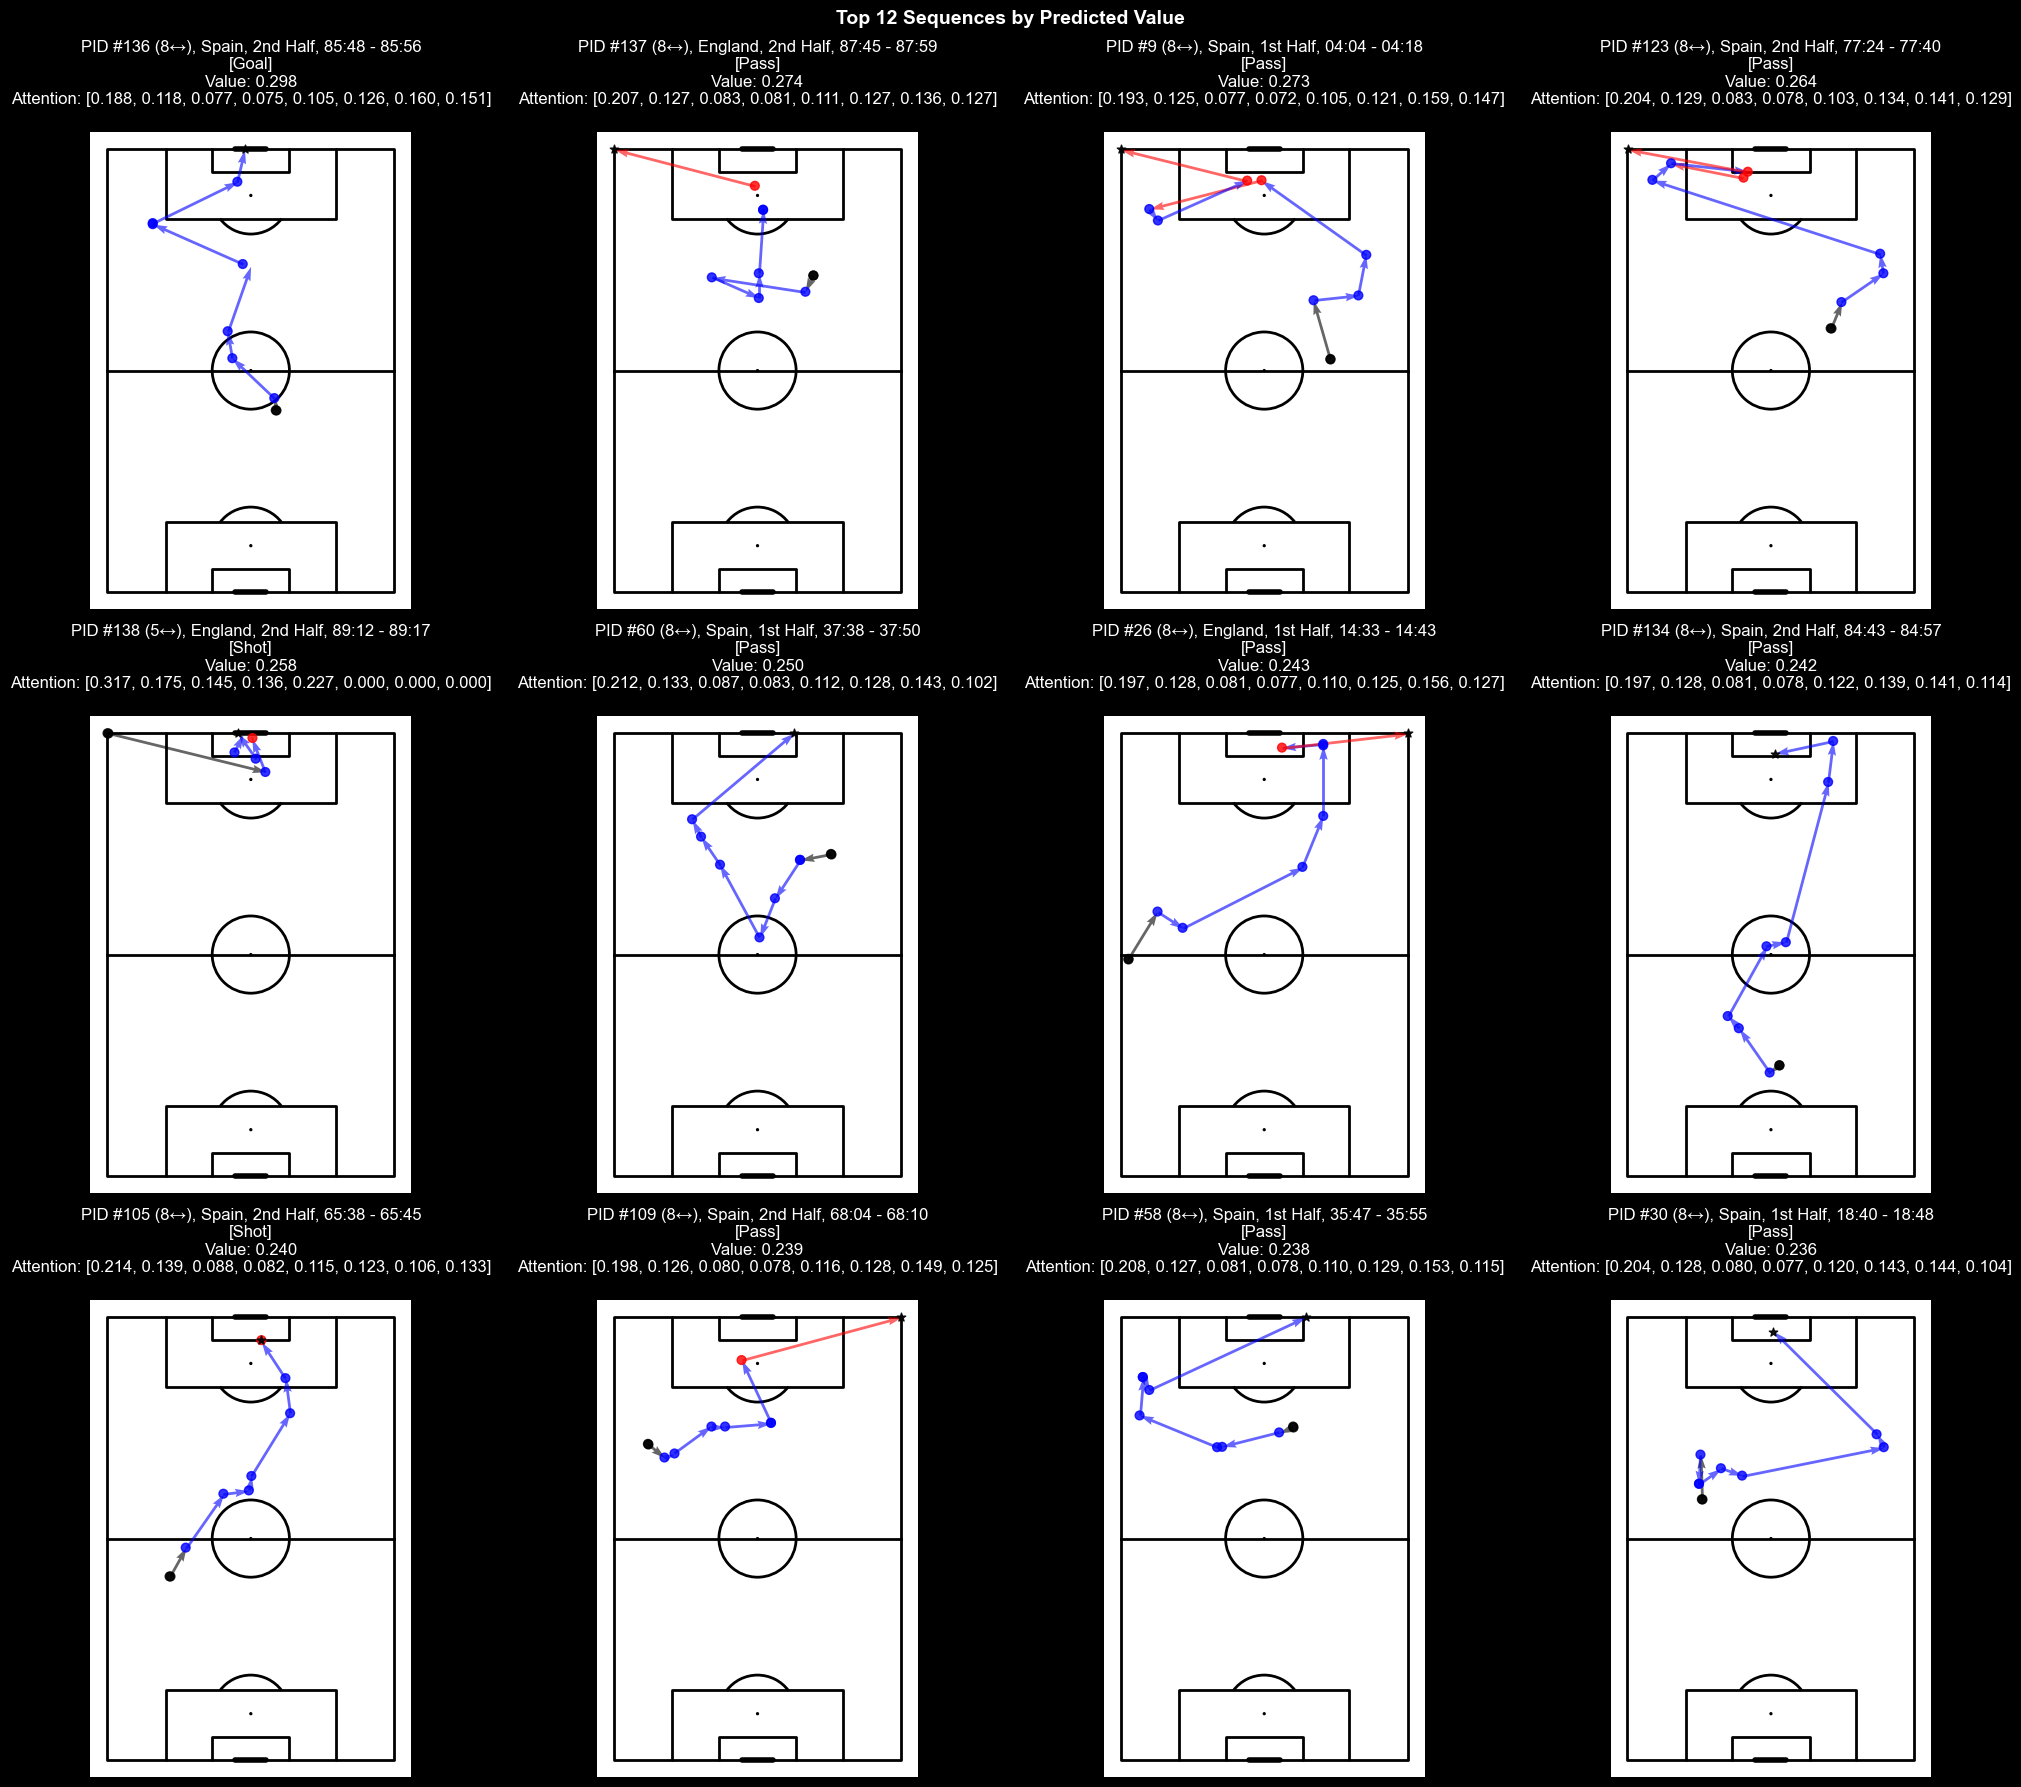

In [627]:
visualize_top_sequences(p, predicted_values, attention_weights, 12, cols=4)
plt.savefig(f"{MODEL_DIR}/top_possessions_final.png", dpi=300)


## 5. Additional Analysis

#### Analyze all possessions with predicted value above a certain threshold

In [628]:
len(p)

124

In [644]:
high_value_indices = np.where(predicted_values >= 0.2)[0]
len(high_value_indices)

14

Processed sequence index: 7 with predicted value: 0.273
Processed sequence index: 20 with predicted value: 0.243
Processed sequence index: 24 with predicted value: 0.236
Processed sequence index: 49 with predicted value: 0.238
Processed sequence index: 51 with predicted value: 0.250
Processed sequence index: 59 with predicted value: 0.228
Processed sequence index: 90 with predicted value: 0.240
Processed sequence index: 94 with predicted value: 0.239
Processed sequence index: 103 with predicted value: 0.217
Processed sequence index: 106 with predicted value: 0.264
Processed sequence index: 116 with predicted value: 0.242
Processed sequence index: 118 with predicted value: 0.298
Processed sequence index: 119 with predicted value: 0.274
Processed sequence index: 120 with predicted value: 0.258


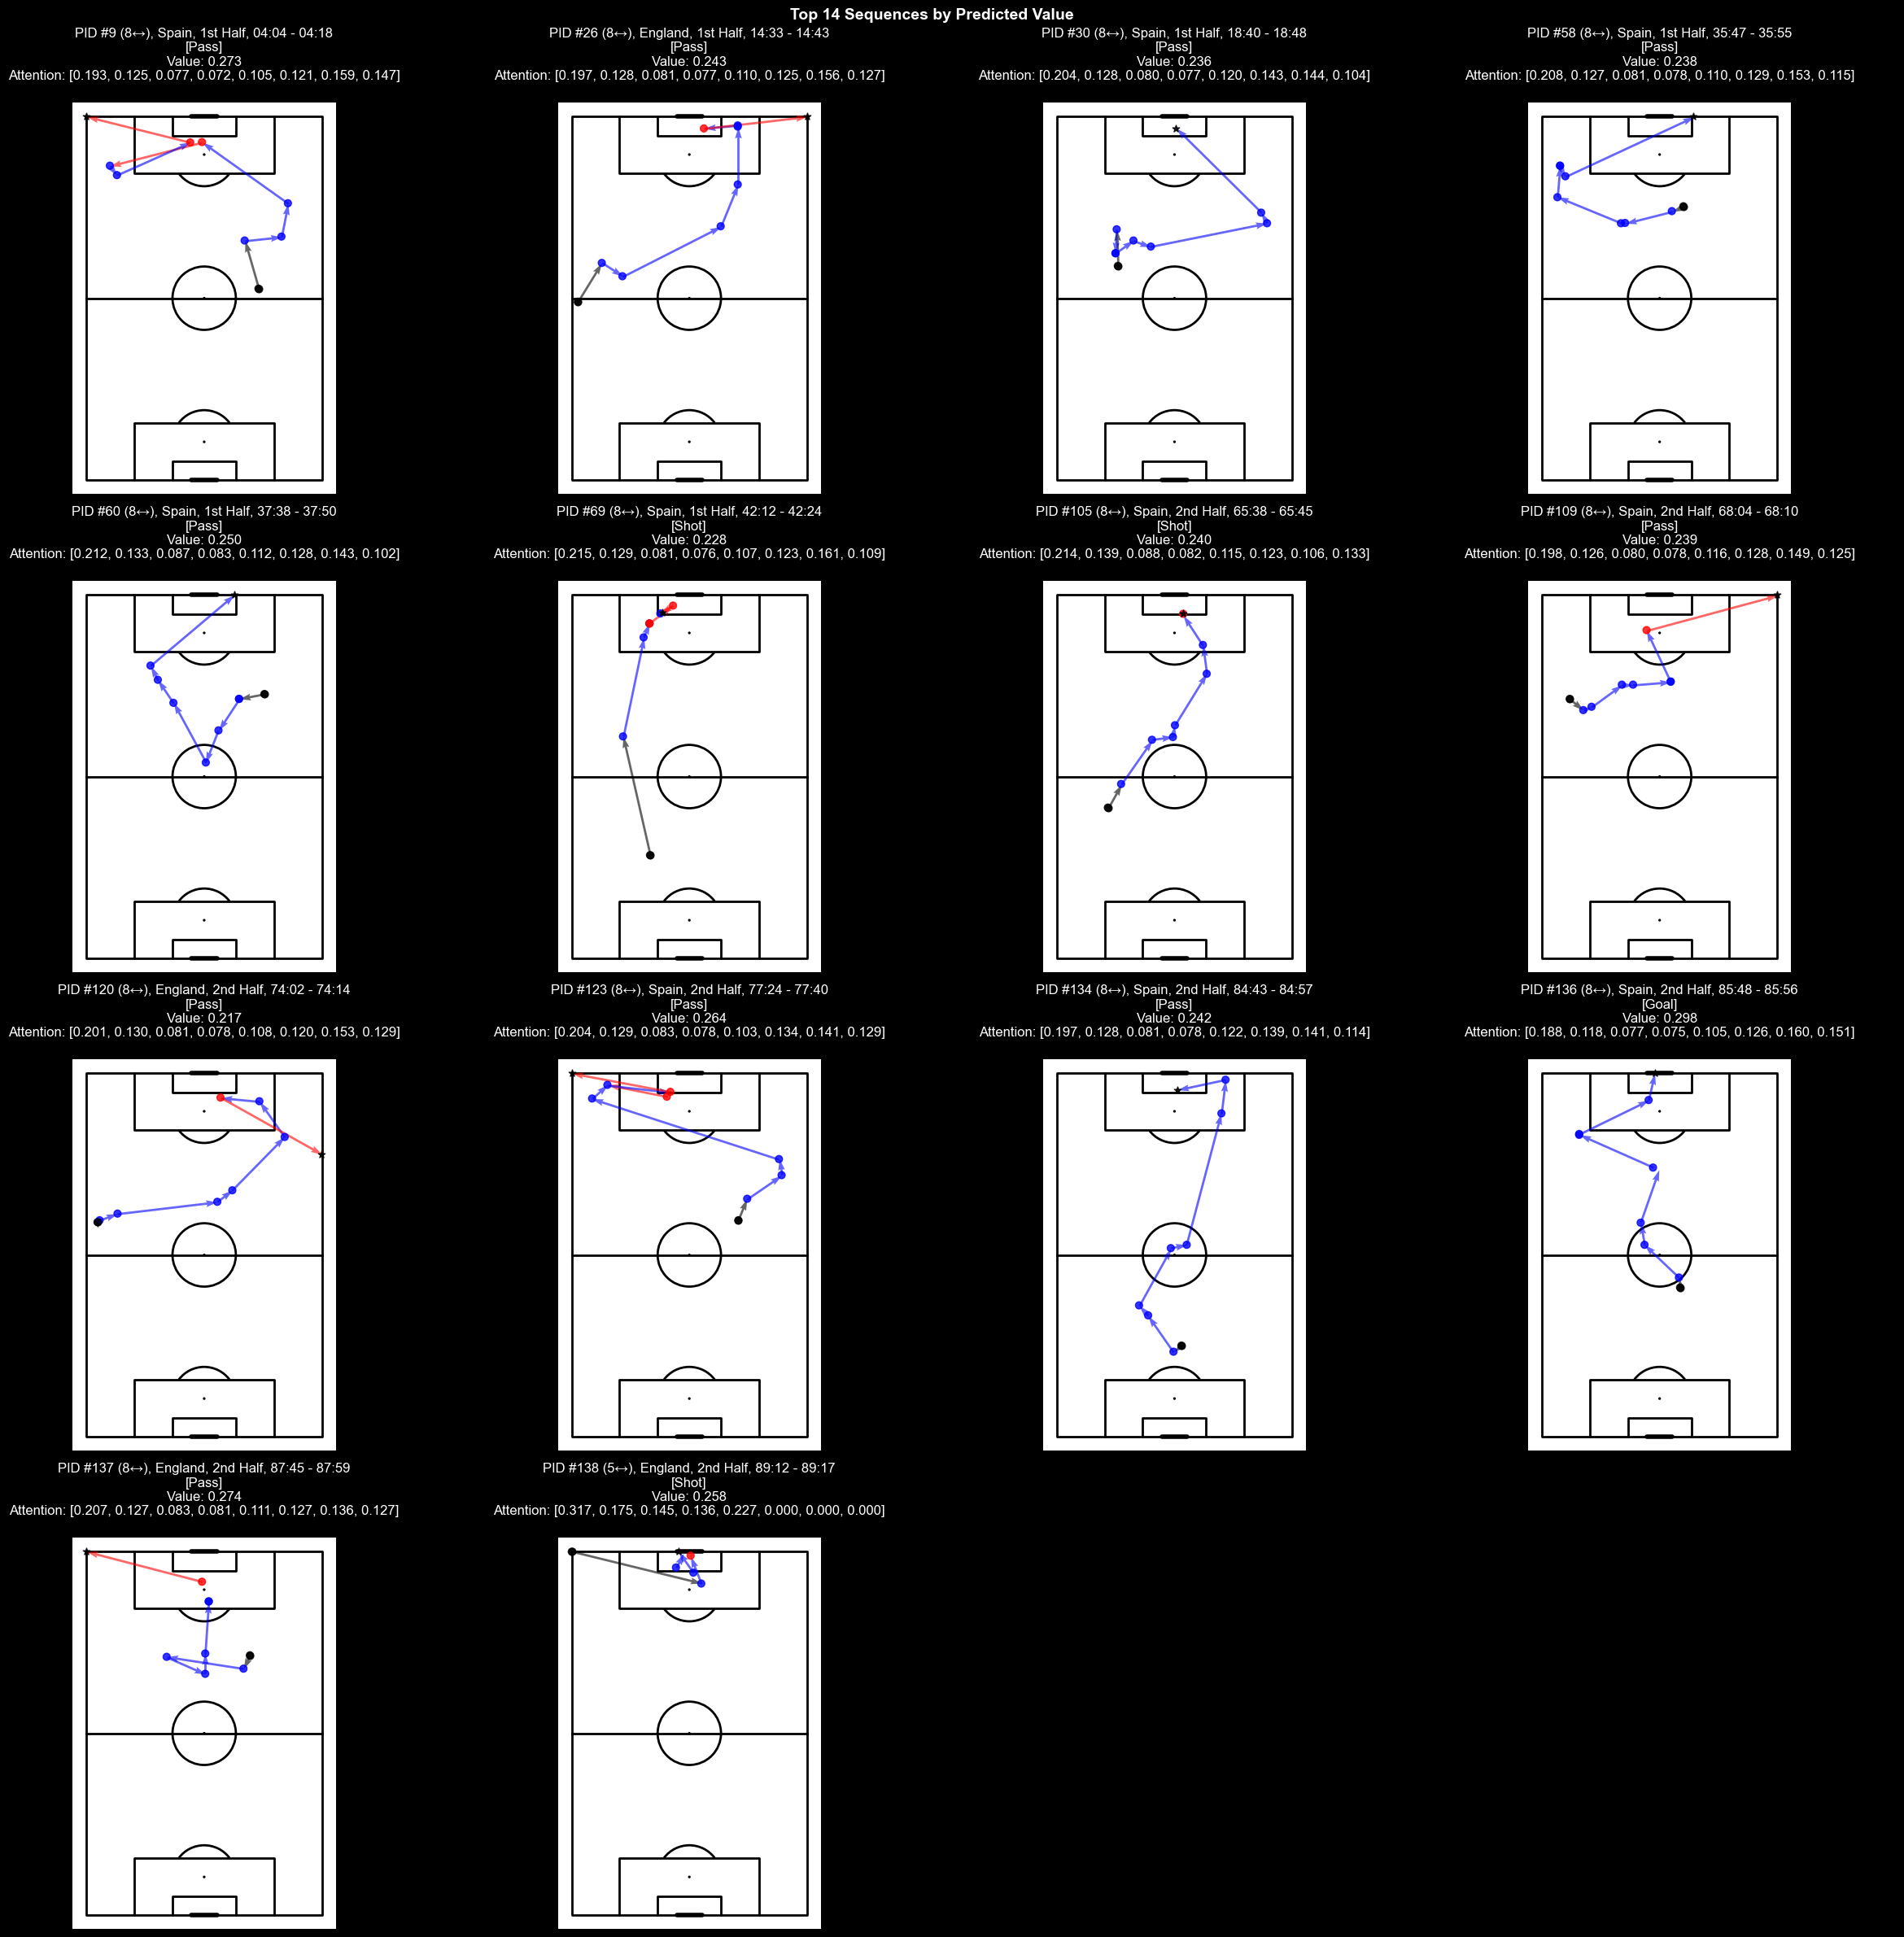

In [645]:
visualize_top_sequences(p, predicted_values, attention_weights, indices=high_value_indices, cols=4)
None

#### Analyse specific possession by index

In [631]:
top_indices = get_top_indices(predicted_values)

Processed sequence index: 16 with predicted value: 0.087
Processed sequence index: 63 with predicted value: 0.169
Processed sequence index: 67 with predicted value: 0.198
Processed sequence index: 69 with predicted value: 0.151
Processed sequence index: 78 with predicted value: 0.055
Processed sequence index: 85 with predicted value: 0.048
Processed sequence index: 90 with predicted value: 0.240
Processed sequence index: 100 with predicted value: 0.108
Processed sequence index: 101 with predicted value: 0.060
Processed sequence index: 111 with predicted value: 0.183
Processed sequence index: 118 with predicted value: 0.298
Processed sequence index: 120 with predicted value: 0.258
Possession ID: 21
    type_name                player_name       xG        xT
277      Pass      Daniel Carvajal Ramos  0.00000  0.016895
278      Pass                Kyle Walker  0.00000  0.014291
279     Carry      Marc Cucurella Saseta  0.00000  0.014291
280      Pass      Marc Cucurella Saseta  0.00000  0.

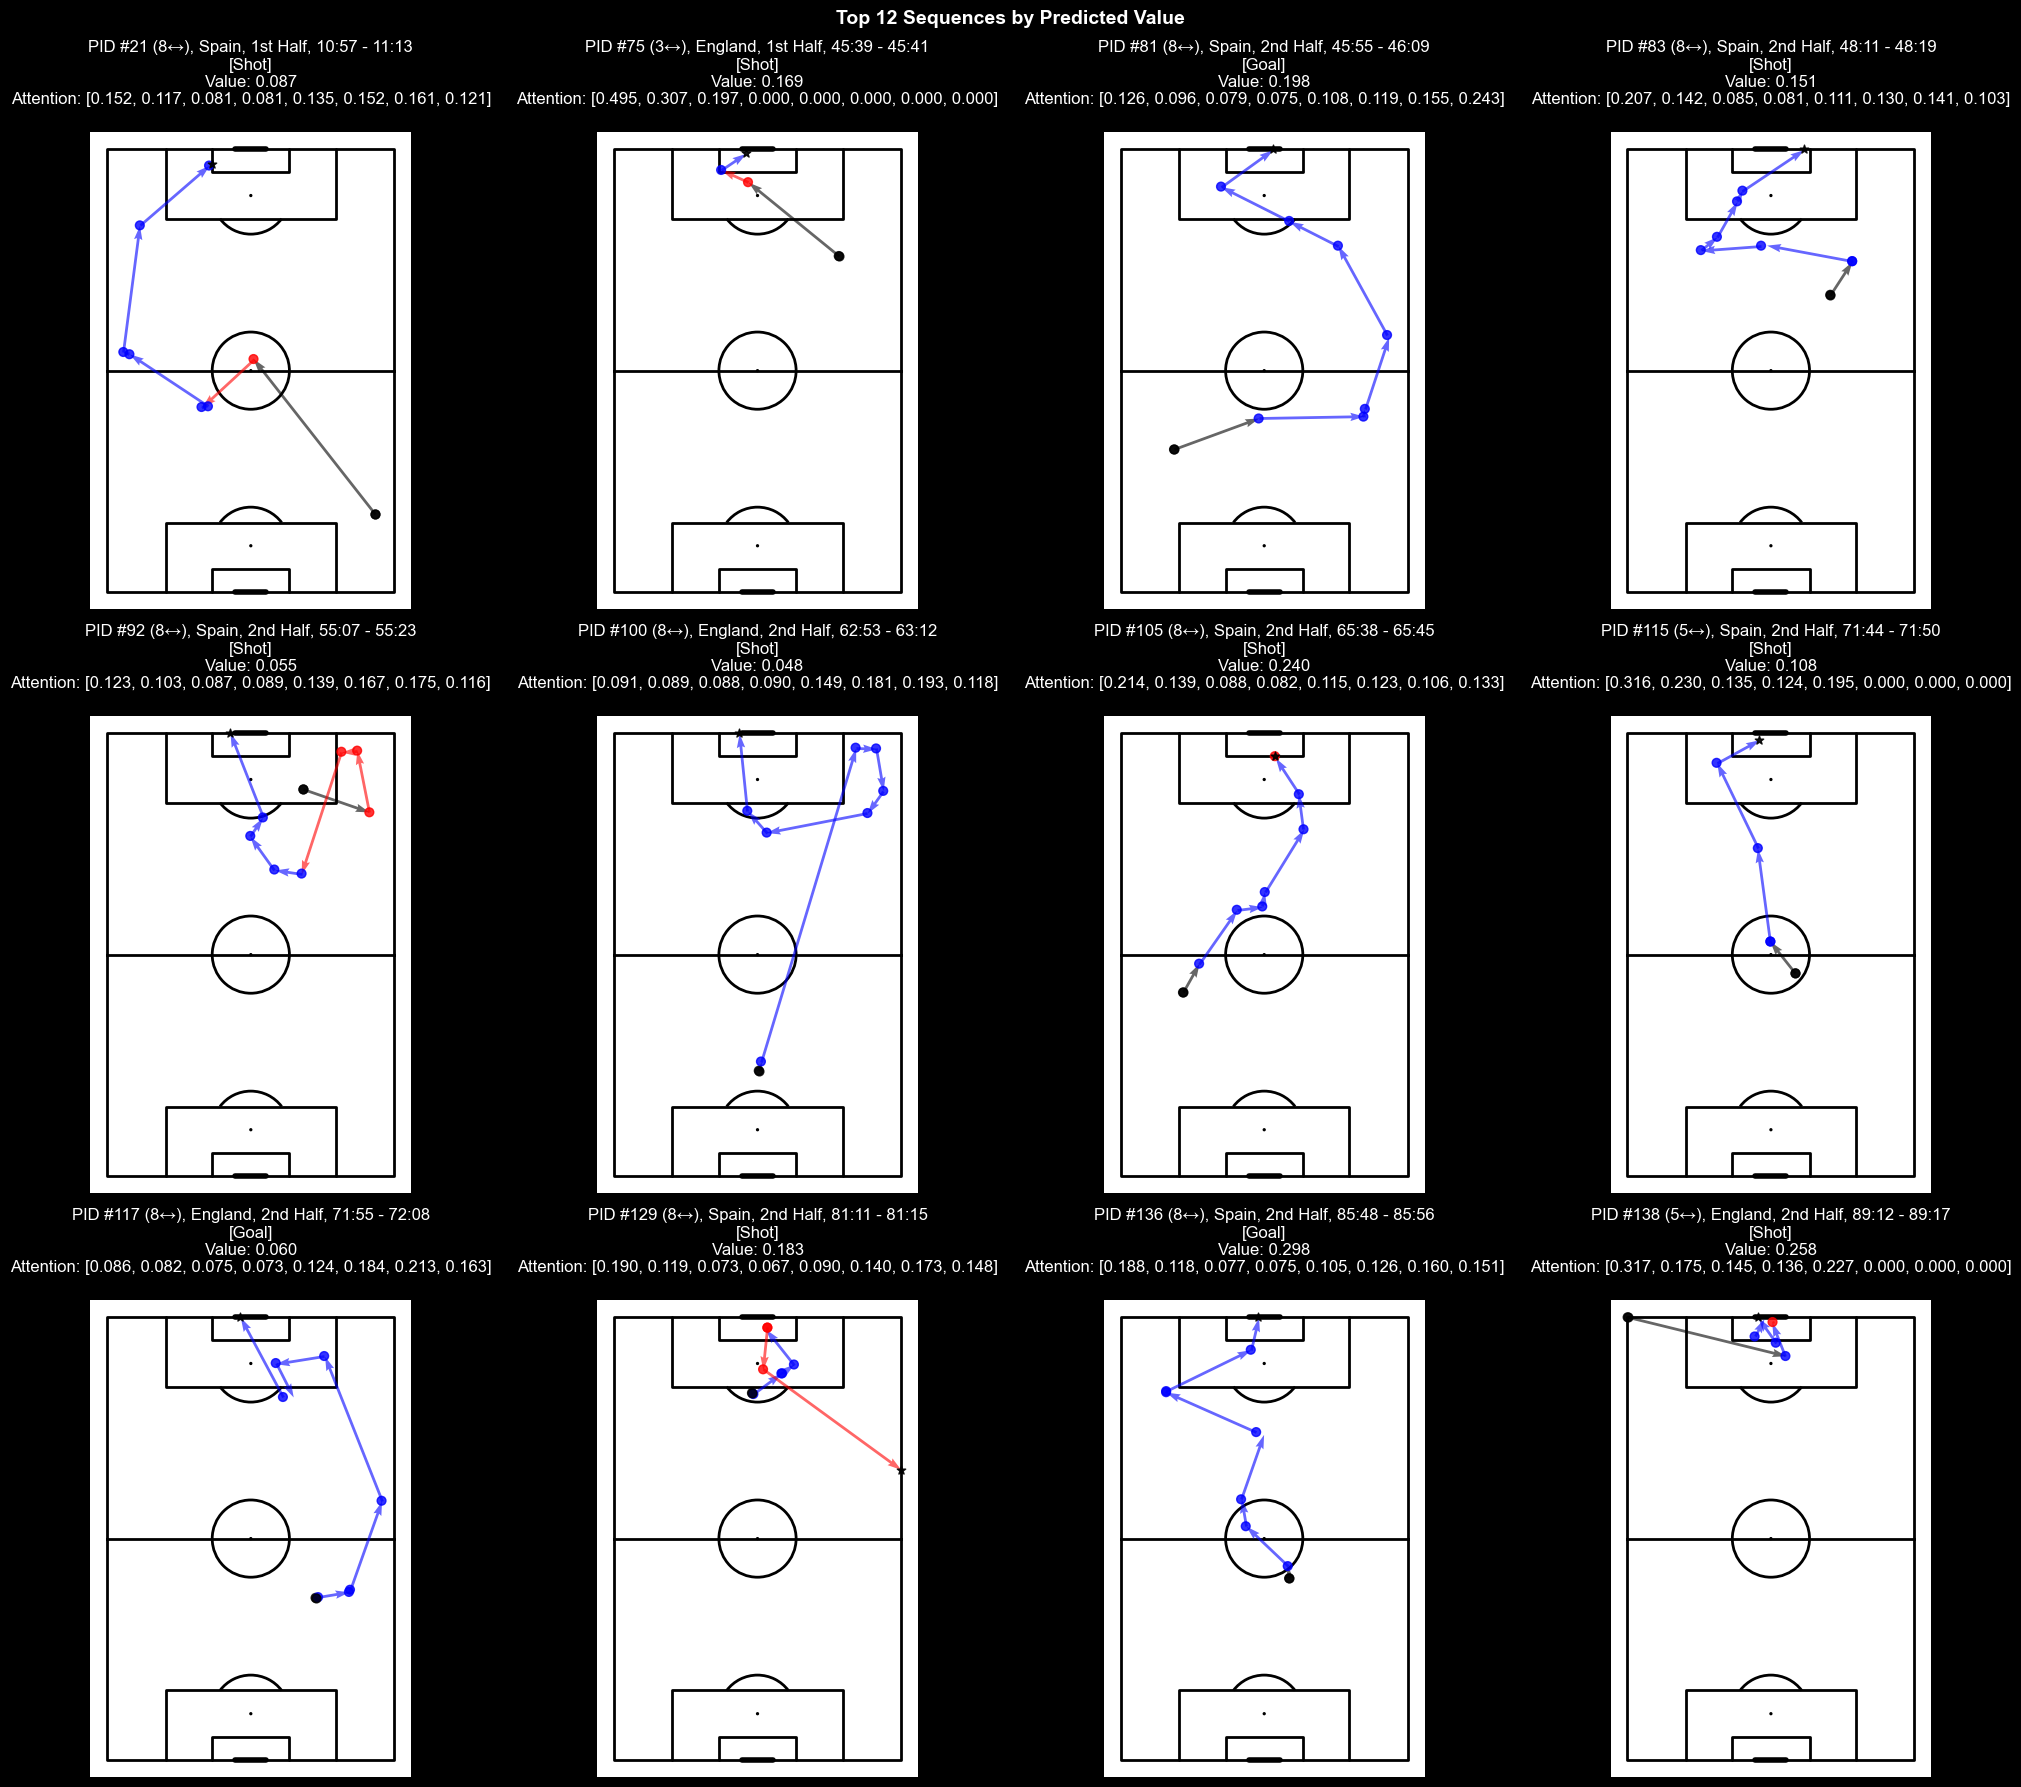

In [632]:
possession_ids = [
    21,
    75,
    81,
    83,
    # brakuje, która jest częścią 92
    92,
    100,
    105,
    115,
    117,
    129,
    136,
    138,
]
indices = [i for i, df in enumerate(p) if df['possession'].iloc[0] in possession_ids]

visualize_top_sequences(p, predicted_values, attention_weights, indices=np.array(indices), cols=4)
for idx in indices:
    print(f"Possession ID: {p[idx]['possession'].iloc[0]}")
    print(p[idx][['type_name', 'player_name', 'xG', 'xT']])
# None
# # plot_possession_actions(p[possession_id])
# # p[possession_id][['type_name', 'player_name', 'xG', 'xT']]

#### Analyze another possession

In [633]:
p[49][['possession','type_name', 'player_name', 'xG', 'xT']]

,possession,type_name,player_name,xG,xT
747,58,Carry,Fabián Ruiz Peña,0.0,0.023851
748,58,Pass,Fabián Ruiz Peña,0.0,0.024122
749,58,Carry,Marc Cucurella Saseta,0.0,0.024122
750,58,Pass,Marc Cucurella Saseta,0.0,0.027563
751,58,Carry,Nicholas Williams Arthuer,0.0,0.034851
752,58,Dribble,Nicholas Williams Arthuer,0.0,0.034851
753,58,Carry,Nicholas Williams Arthuer,0.0,0.034851
754,58,Pass,Nicholas Williams Arthuer,0.0,0.064426


#### Find sequences with length less then SEQUENCE_LENGTH

In [634]:
p[0]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
0,3943043,152820f0-6ca9-4df3-943b-a67d568ff472,1,0.340,768,99174.0,52.45625,34.0425,22.18125,35.0625,0,1,5,0,England,Kobbie Mainoo,2,Pass,2.529454,False,False,0.0,768,England,0.010165,-30.2750,1.020,30.292178,3.107914,0.000,0
1,3943043,9c107df3-a3c8-4ad5-bc35-00214087a105,1,2.870,768,3468.0,22.18125,35.0625,25.06875,41.1825,21,1,0,1,England,Jordan Pickford,2,Carry,1.872089,False,False,0.0,768,England,0.010165,2.8875,6.120,6.766983,1.129951,2.530,0
2,3943043,237201b8-aef8-4823-b282-e82875795c07,1,4.742,768,3468.0,25.06875,41.1825,104.95625,10.4975,0,0,4,2,England,Jordan Pickford,2,Pass,5.137795,False,False,0.0,768,England,0.046477,79.8875,-30.685,85.577929,-0.366727,1.872,0


In [635]:
short_sequence_ids = np.array([i for i, df in enumerate(p) if len(df) < config.SEQUENCE_LENGTH])
print(f"IDs of short sequences: {short_sequence_ids}")

IDs of short sequences: [  0   4   8   9  11  13  17  19  22  25  28  29  31  32  33  35  40  46
  47  50  60  61  63  64  65  68  72  74  79  86  88  89  91  92  93  96
  99 100 105 107 110 113 114 120 121 122 123]


#### Create X_short_sequences and p_short_sequences

In [636]:
X_short_sequences = X[short_sequence_ids]
p_short_sequences = p[short_sequence_ids]

print(f"X_short_sequences shape: {X_short_sequences.shape}")
print(f"Number of short sequences: {len(p_short_sequences)}")

X_short_sequences shape: (47, 8, 46)
Number of short sequences: 47


#### Make predictions on short sequences

In [637]:
predictions_short = model.predict(X_short_sequences, batch_size=32, verbose=0)
predicted_values_short, attention_weights_short = normalize_predictions(predictions_short)

print(f"Total short sequences analyzed: {len(predicted_values_short)}")
print(f"Sum of predicted values: {predicted_values_short.sum():.3f}")
print(f"Has attention weights: {attention_weights_short is not None}")

Total short sequences analyzed: 47
Sum of predicted values: 1.939
Has attention weights: True


#### Visualize short sequences

Processed sequence index: 43 with predicted value: 0.258
Processed sequence index: 22 with predicted value: 0.169
Processed sequence index: 6 with predicted value: 0.163
Processed sequence index: 39 with predicted value: 0.124
Processed sequence index: 37 with predicted value: 0.108
Processed sequence index: 13 with predicted value: 0.100
Processed sequence index: 35 with predicted value: 0.091
Processed sequence index: 23 with predicted value: 0.081


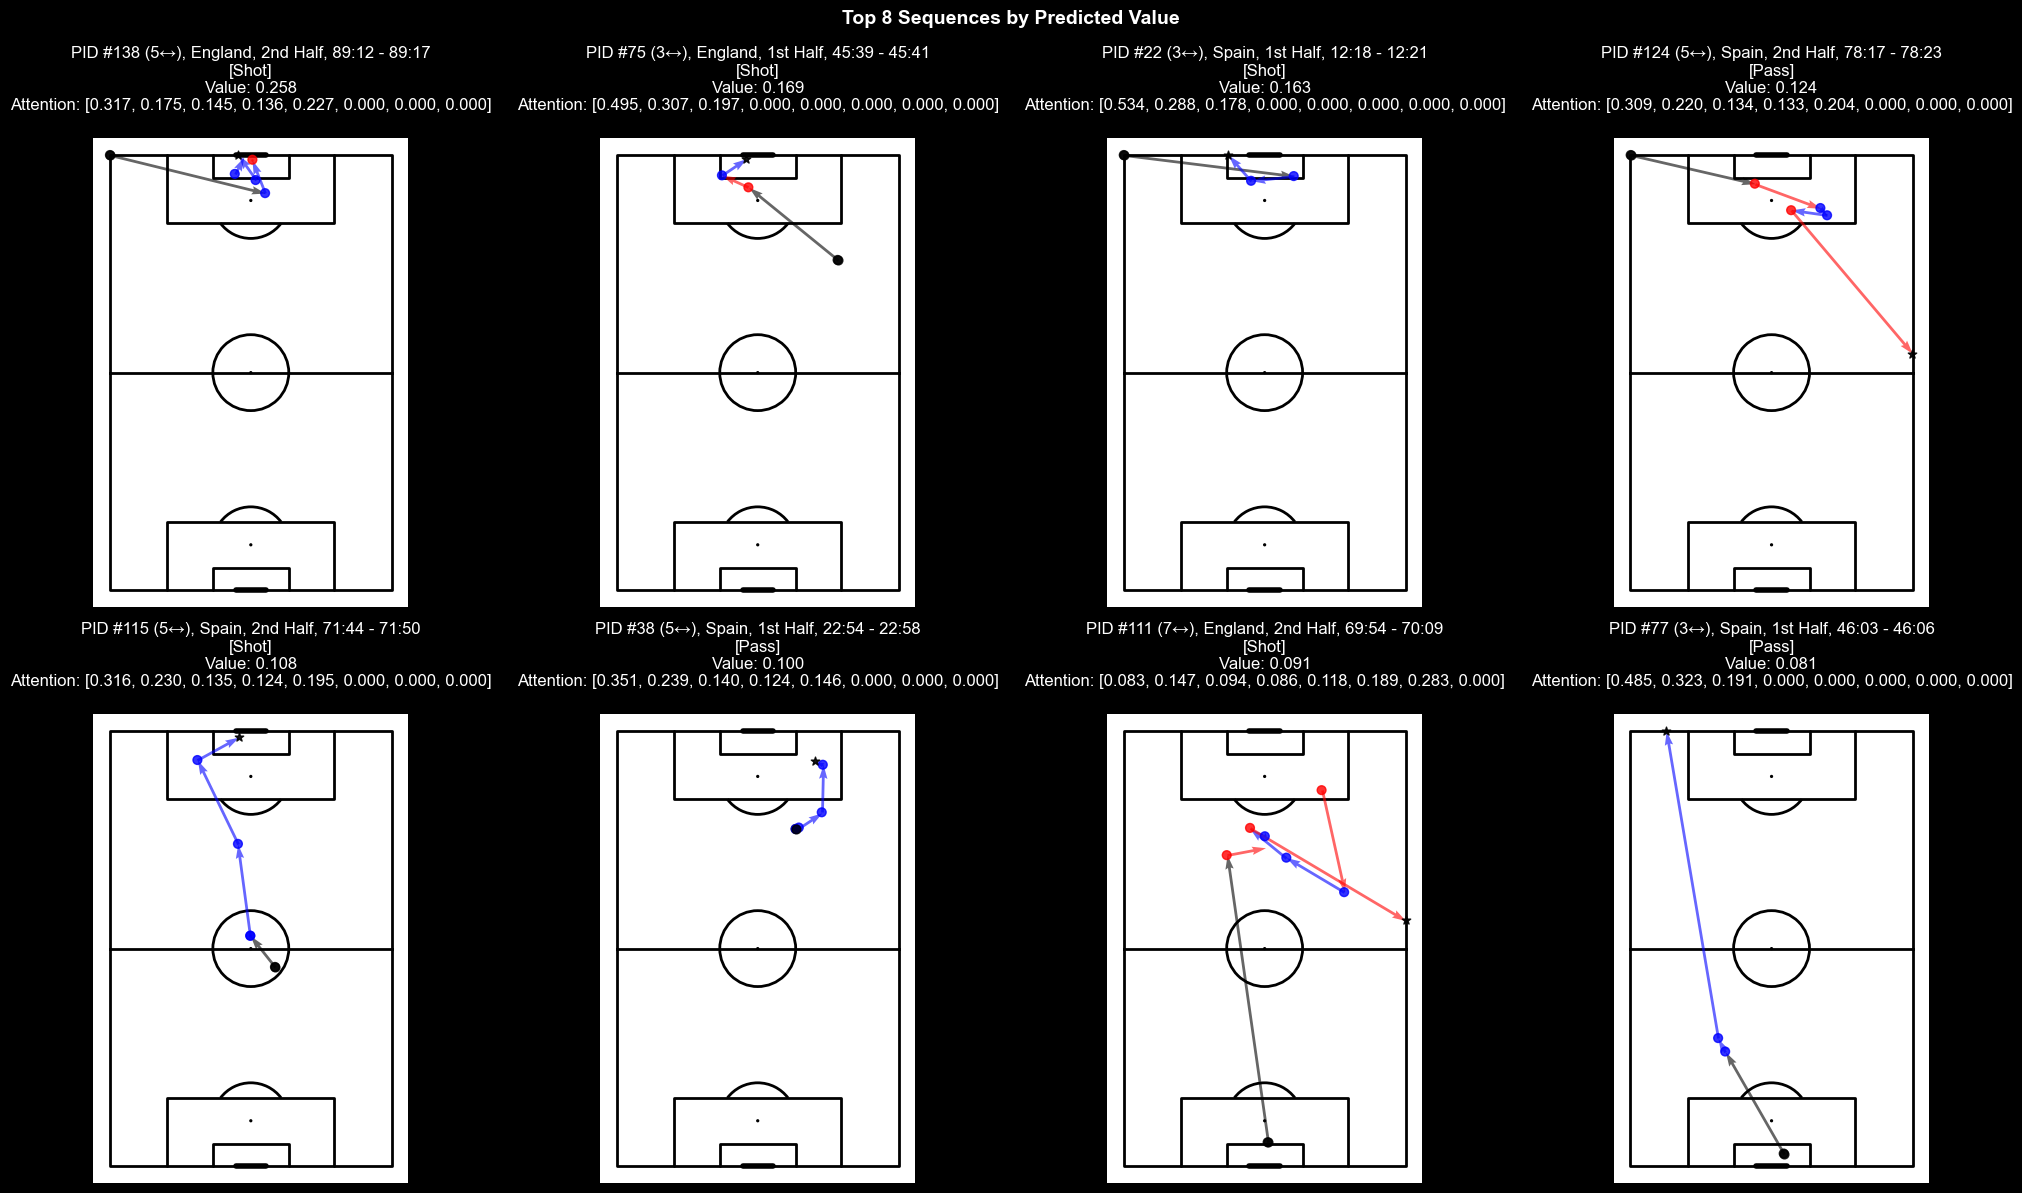

In [638]:
visualize_top_sequences(p_short_sequences, predicted_values_short, attention_weights_short, 8, cols=4)
plt.savefig(f"models/{MODEL_TYPE}/top_possessions_short_sequences.png", dpi=300)


#### Get top indices from short sequences

In [639]:
top_indices_short = get_top_indices(predicted_values_short)
top_indices_short

array([43, 22,  6, 39, 37, 13, 35, 23,  2, 38,  0, 33, 32, 46, 25, 42, 44,
       10, 19, 17, 14, 27, 26, 31, 36, 30,  9, 40, 29,  7, 15, 11, 45, 24,
        5,  3, 21, 34, 28,  8,  1, 16, 18, 41, 12, 20,  4])

Processed sequence index: 35 with predicted value: 0.091


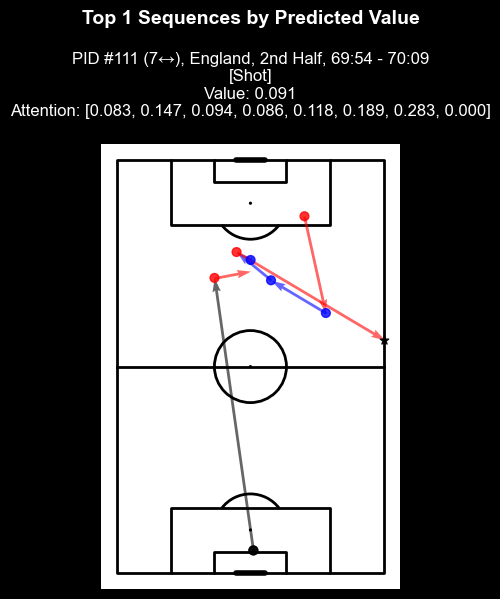

In [640]:
visualize_top_sequences(p_short_sequences, predicted_values_short, attention_weights_short, indices=np.array([35]))
None

In [641]:
p_short_sequences[35]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
1466,3943043,ee3965c5-7ea2-4405-9d33-3bf4bcd89538,2,1494.999,768,3468.0,5.81875,33.2775,75.03125,43.1375,22,0,4,1466,England,Jordan Pickford,111,Pass,3.873401,False,False,0.000000,768,England,0.009411,69.2125,9.860,69.911299,0.141508,0.000,0
1467,3943043,2b56f4f6-ba40-43c1-b08b-729e47adc9da,2,1498.872,772,5721.0,75.03125,43.1375,76.78125,33.8725,0,0,1,1467,Spain,Daniel Carvajal Ramos,111,Pass,0.817431,False,False,0.000000,768,England,0.023851,1.7500,-9.265,9.428824,-1.384113,3.873,1
1468,3943043,be6417cc-b3ec-4a67-a4b2-e6648b14566d,2,1499.964,768,4760.0,79.58125,33.9575,80.63125,34.0425,11,0,5,1468,England,Ollie Watkins,111,Shot,0.018527,True,False,0.074709,768,England,0.035113,1.0500,0.085,1.053435,0.080776,1.092,0
1469,3943043,785459cb-64aa-4d0b-87e0-b69ae592c3b2,2,1502.188,772,4353.0,90.69375,20.2725,66.10625,14.8325,18,1,4,1469,Spain,Aymeric Laporte,111,Clearance,0.000000,True,False,0.000000,768,England,0.054911,-24.5875,-5.440,25.182112,-2.923850,2.224,1
1470,3943043,55208b6e-d847-4a73-93cd-8bf0e9d61bef,2,1505.318,768,30714.0,66.10625,14.8325,74.41875,28.7725,21,1,0,1470,England,Jude Bellingham,111,Carry,3.429030,True,False,0.000000,768,England,0.023851,8.3125,13.940,16.230257,1.033098,3.130,0
1471,3943043,540e7ddf-44b3-435f-a4fe-5dbdf522d835,2,1508.747,768,30714.0,74.41875,28.7725,81.59375,37.5275,0,0,5,1471,England,Jude Bellingham,111,Pass,1.071324,True,False,0.000000,768,England,0.035113,7.1750,8.755,11.319481,0.884259,3.429,0
1472,3943043,166eb4c8-d6f5-4c14-a8d6-c132cf2f19a4,2,1509.818,772,22128.0,81.59375,37.5275,59.28125,0.0425,0,0,5,1472,Spain,Robin Aime Robert Le Normand,111,Pass,2.783475,False,False,0.000000,768,England,0.014736,-22.3125,-37.485,43.623077,-2.107707,1.071,1


In [642]:
X_short_sequences[35]

array([[ 5.54166660e-02,  4.89374995e-01,  7.14583337e-01,
         6.34374976e-01,  6.65821910e-01,  1.41035855e-01,
         9.90004480e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 7.14583337e-01,  6.34374976e-01,  7.31249988e-01,
         4.98124987e-01,  8.97

In [643]:
attention_weights_short[35]

array([0.08256918, 0.14709957, 0.09440681, 0.0857335 , 0.11788112,
       0.18893965, 0.28337014, 0.        ], dtype=float32)